In [1]:
import os,sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from plotnine import *
import re
import glob

In [2]:
path_process = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster'
exclude = ['plots', 'qc_stats', 'qc_stats_welch']
folders = sorted([
    f for f in os.listdir(path_process) 
    if os.path.isdir(os.path.join(path_process, f)) 
    and not f.startswith('.') 
    and f not in exclude
])

In [3]:
df_rest = []
df_stim = []
for folder in folders:
    pattern = glob.glob(os.path.join(path_process, folder, 'guide_assigned.csv'))[0]
    df_cell = pd.read_csv(pattern)
    df_cell['sample_name'] = folder
    if 'Rest' in folder:
        df_rest.append(df_cell)
    if 'Stim' in folder:
        df_stim.append(df_cell)

In [4]:
df_cell_rest = pd.concat(df_rest, axis = 0)
df_cell_stim = pd.concat(df_stim, axis= 0)

In [5]:
# Rest
df_guide_rest = pd.DataFrame(df_cell_rest.groupby('cell').size(), columns=['number_of_guides'])
df_guide_rest['donor'] = df_guide_rest.index.str.split('_').str[2]
df_guide_rest['construct'] = df_guide_rest.index.str.split('_').str[3]
df_guide_rest['condition'] = df_guide_rest.index.str.split('_').str[4]
# Stim
df_guide_stim = pd.DataFrame(df_cell_stim.groupby('cell').size(), columns=['number_of_guides'])
df_guide_stim['donor'] = df_guide_stim.index.str.split('_').str[2]
df_guide_stim['construct'] = df_guide_stim.index.str.split('_').str[3]
df_guide_stim['condition'] = df_guide_stim.index.str.split('_').str[4]
df_guide_stim.head()

,number_of_guides,donor,construct,condition
cell,,,,
AAACAAGCAAACAAGAAACGCCGA-1_lane1_D1_408i_Stim,2,D1,408i,Stim
AAACAAGCAAACCGGTAACGCCGA-1_lane6_D1_408i_Stim,2,D1,408i,Stim
AAACAAGCAAACCGGTACTACTCA-1_lane6_D2_407a_Stim,1,D2,407a,Stim
AAACAAGCAAACCGTAACAGTCTG-1_lane2_D1_400a_Stim,2,D1,400a,Stim
AAACAAGCAAACCGTAATTCGGTT-1_lane2_D2_408i_Stim,1,D2,408i,Stim


In [7]:
df_guide =  pd.concat([df_guide_rest, df_guide_stim], axis=0)

In [ ]:
plt_path = '/Users/chandrima.modak/Gladstone Dropbox/Chandrima Modak/gw-CRISPRa_from_cluster/plots'

### Number of Guide assigned per cell by condition

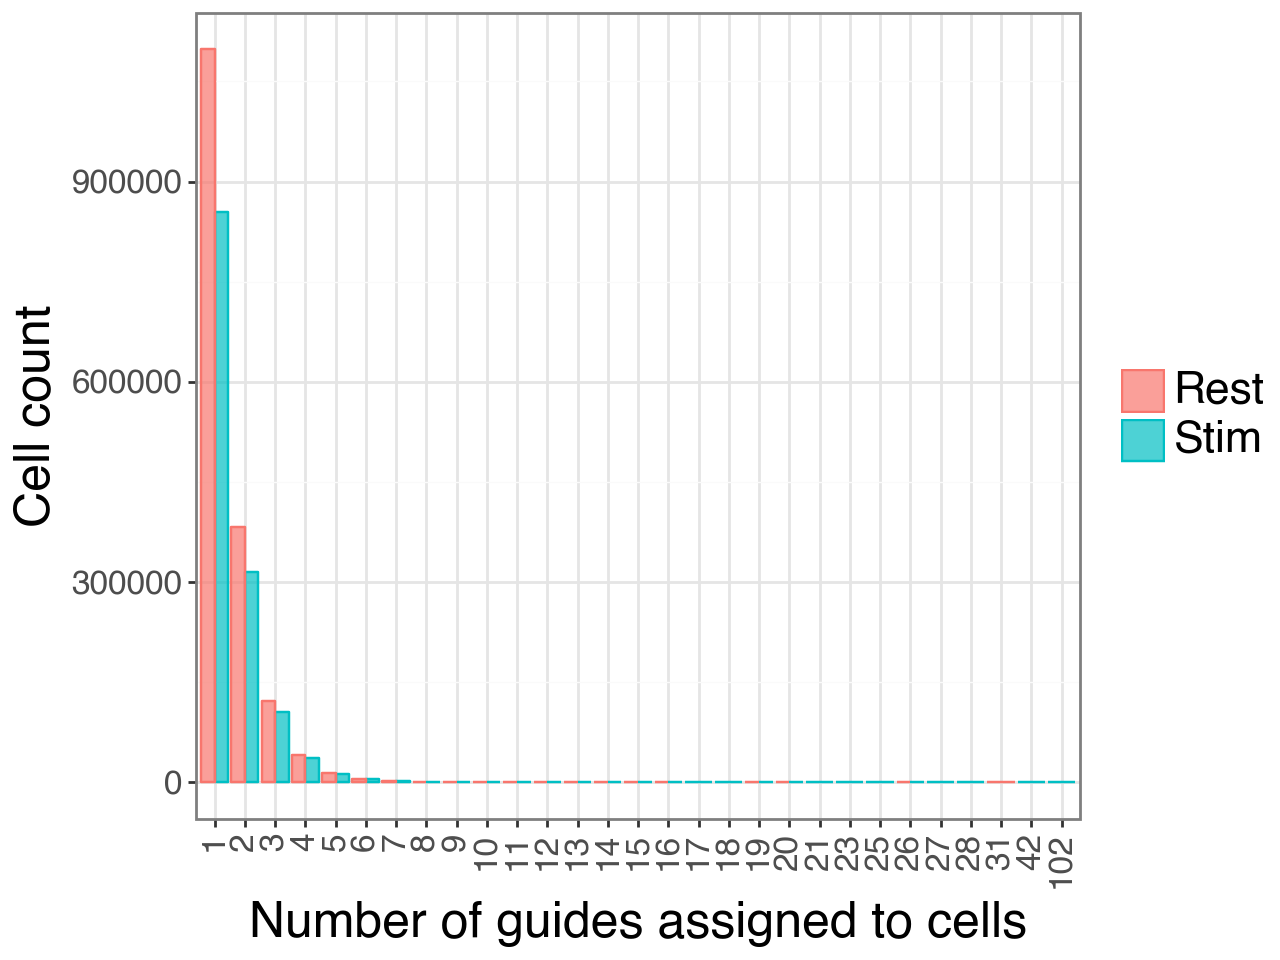

In [8]:
p = (
    ggplot(df_guide, aes(x='factor(number_of_guides)', fill='condition')) 
    + geom_bar(aes(color='condition'), alpha=0.7, position='dodge')
    + labs(x='Number of guides assigned to cells', 
           y='Cell count')
    + theme_bw()
    + theme(legend_title=element_blank(),
           legend_text = element_text(size = 16))
    +theme(
            plot_title = element_text(size = 16, face = "bold"),
            axis_title_x = element_text(size = 18),
            axis_title_y = element_text(size = 18),
            axis_text_x = element_text(size = 12,angle = 90), # Size of tick labels
            axis_text_y = element_text(size = 12)  # Size of tick labels
              )
)
# p.save(os.path.join(plt_path, 'guides_count_per_cell.png'), dpi= 150)
p.show()


### Number of Guide assigned per cell by construct

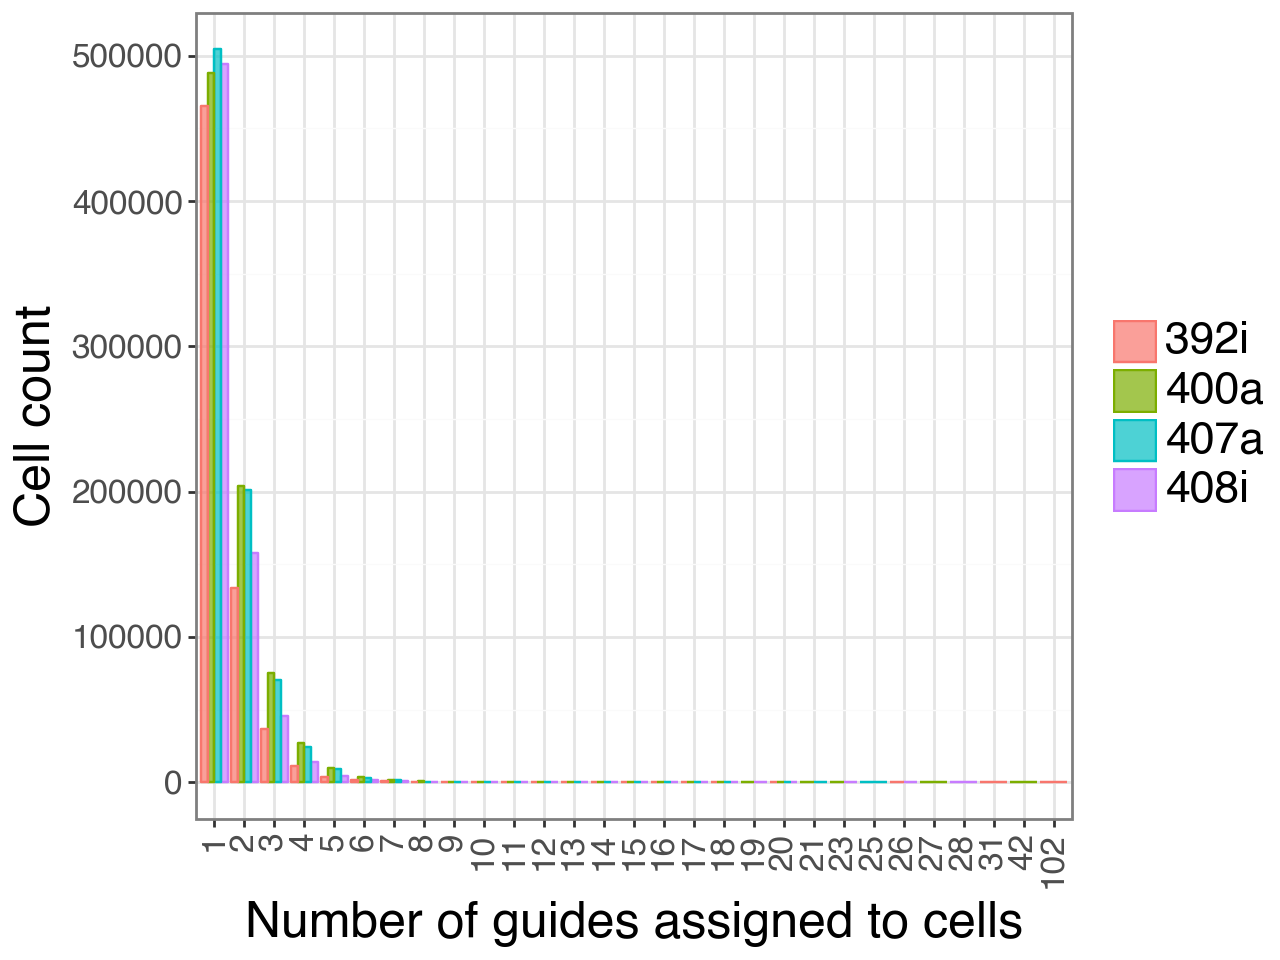

In [9]:
p = (
    ggplot(df_guide, aes(x='factor(number_of_guides)', fill='construct')) 
    + geom_bar(aes(color='construct'), alpha=0.7, position='dodge')
    + labs(x='Number of guides assigned to cells', 
           y='Cell count')
    + theme_bw()
    + theme(legend_title=element_blank(),
           legend_text = element_text(size = 16))
    +theme(
            plot_title = element_text(size = 16, face = "bold"),
            axis_title_x = element_text(size = 18),
            axis_title_y = element_text(size = 18),
            axis_text_x = element_text(size = 12,angle = 90), # Size of tick labels
            axis_text_y = element_text(size = 12)  # Size of tick labels
              )
)
# p.save(os.path.join(plt_path, 'guides_count_per_cell.png'), dpi= 150)
p.show()

### Number of Guide assigned per cell by donor

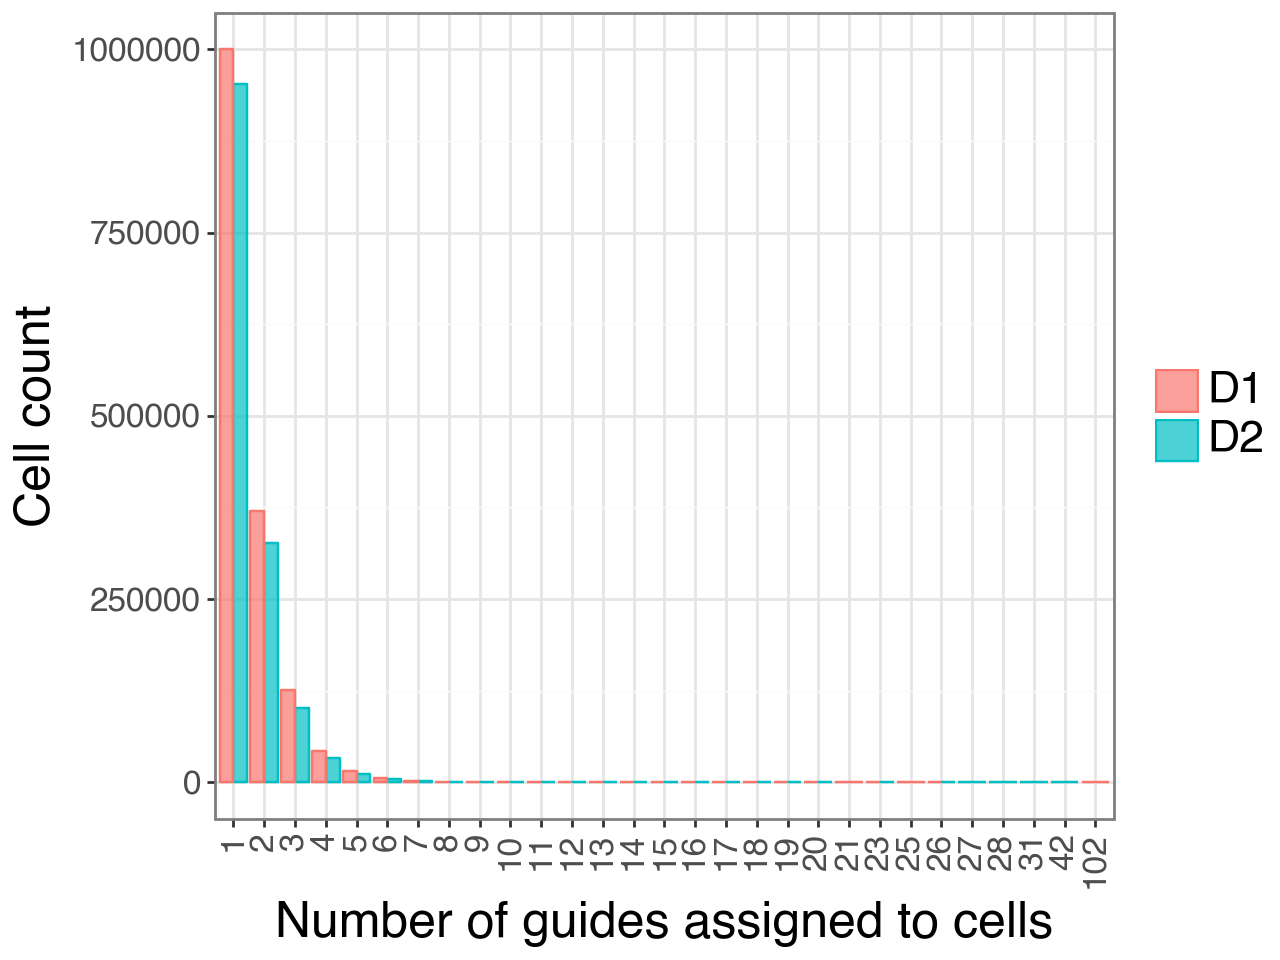

In [10]:
p = (
    ggplot(df_guide, aes(x='factor(number_of_guides)', fill='donor')) 
    + geom_bar(aes(color='donor'), alpha=0.7, position='dodge')
    + labs(x='Number of guides assigned to cells', 
           y='Cell count')
    + theme_bw()
    + theme(legend_title=element_blank(),
           legend_text = element_text(size = 16))
    +theme(
            plot_title = element_text(size = 16, face = "bold"),
            axis_title_x = element_text(size = 18),
            axis_title_y = element_text(size = 18),
            axis_text_x = element_text(size = 12,angle = 90), # Size of tick labels
            axis_text_y = element_text(size = 12)  # Size of tick labels
              )
)
# p.save(os.path.join(plt_path, 'guides_count_per_cell.png'), dpi= 150)
p.show()

In [7]:
df_cell_rest['target_gene'] = df_cell_rest.gRNA.apply(lambda x : x.replace('-', '_').split('_')[0])
df_cell_rest

,cell,gRNA,UMI_counts,sample_name,target_gene
0,ACCAATTTCAGCTACCACAGACCT-1_lane1_D1_392i_Rest,ACAT1_A_CRISPRi_1,148.0,D1_392i_Rest_lane1,ACAT1
1,ACGGACCAGCATGTGGACAGACCT-1_lane1_D1_392i_Rest,ACAT1_A_CRISPRi_1,3.0,D1_392i_Rest_lane1,ACAT1
2,ACTCCCACAAACGGTCACAGACCT-1_lane1_D1_392i_Rest,ACAT1_A_CRISPRi_1,83.0,D1_392i_Rest_lane1,ACAT1
3,AGGACAAAGTCTGTGCACAGACCT-1_lane1_D1_392i_Rest,ACAT1_A_CRISPRi_1,235.0,D1_392i_Rest_lane1,ACAT1
4,AGTAACCAGACTAACAACAGACCT-1_lane1_D1_392i_Rest,ACAT1_A_CRISPRi_1,10.0,D1_392i_Rest_lane1,ACAT1
...,...,...,...,...,...
26595,GTTTGGTGTACAAACGAGCTGTGA-1_lane8_D2_408i_Rest,NTC-966,10.0,D2_408i_Rest_lane8,NTC
26596,TAGGTTGCAGTGAGAGAGCTGTGA-1_lane8_D2_408i_Rest,NTC-966,36.0,D2_408i_Rest_lane8,NTC
26597,TATACCTAGTTACACTAGCTGTGA-1_lane8_D2_408i_Rest,NTC-966,32.0,D2_408i_Rest_lane8,NTC
26598,TGCGCCTCAATAGCTGAGCTGTGA-1_lane8_D2_408i_Rest,NTC-966,117.0,D2_408i_Rest_lane8,NTC


In [9]:
df_cell_stim['target_gene'] = df_cell_stim.gRNA.apply(lambda x : x.replace('-', '_').split('_')[0])

In [57]:
df_cell_rest.groupby(['target_gene', 'sample_name']).size().to_frame().reset_index()

,target_gene,sample_name,0
0,A4GALT,D1_400a_Rest_lane1,129
1,A4GALT,D1_400a_Rest_lane2,78
2,A4GALT,D1_400a_Rest_lane3,71
3,A4GALT,D1_400a_Rest_lane4,88
4,A4GALT,D1_400a_Rest_lane5,104
...,...,...,...
18897,ZXDA,D2_407a_Rest_lane4,168
18898,ZXDA,D2_407a_Rest_lane5,199
18899,ZXDA,D2_407a_Rest_lane6,177
18900,ZXDA,D2_407a_Rest_lane7,152


In [64]:
#rest
cell_count_rest = df_cell_rest.groupby(['target_gene', 'sample_name']).size().to_frame().reset_index()
cell_count_rest.columns = ['target_gene', 'sample_name','num_of_cells']
cell_count_rest = cell_count_rest[cell_count_rest['target_gene'] != 'NTC']
cell_count_rest['donor'] = cell_count_rest.sample_name.str.split('_').str[0]
cell_count_rest['construct'] = cell_count_rest.sample_name.str.split('_').str[1]
cell_count_rest['condition'] = cell_count_rest.sample_name.str.split('_').str[2]
#stim
cell_count_stim = df_cell_stim.groupby(['target_gene', 'sample_name']).size().to_frame().reset_index()
cell_count_stim.columns = ['target_gene', 'sample_name','num_of_cells']
cell_count_stim = cell_count_stim[cell_count_stim['target_gene'] != 'NTC']
cell_count_stim['donor'] = cell_count_stim.sample_name.str.split('_').str[0]
cell_count_stim['construct'] = cell_count_stim.sample_name.str.split('_').str[1]
cell_count_stim['condition'] = cell_count_stim.sample_name.str.split('_').str[2]

In [63]:
cell_count_rest

,target_gene,sample_name,num_of_cells,donor,construct,condition
0,A4GALT,D1_400a_Rest_lane1,129,D1,400a,Rest
1,A4GALT,D1_400a_Rest_lane2,78,D1,400a,Rest
2,A4GALT,D1_400a_Rest_lane3,71,D1,400a,Rest
3,A4GALT,D1_400a_Rest_lane4,88,D1,400a,Rest
4,A4GALT,D1_400a_Rest_lane5,104,D1,400a,Rest
...,...,...,...,...,...,...
18897,ZXDA,D2_407a_Rest_lane4,168,D2,407a,Rest
18898,ZXDA,D2_407a_Rest_lane5,199,D2,407a,Rest
18899,ZXDA,D2_407a_Rest_lane6,177,D2,407a,Rest
18900,ZXDA,D2_407a_Rest_lane7,152,D2,407a,Rest


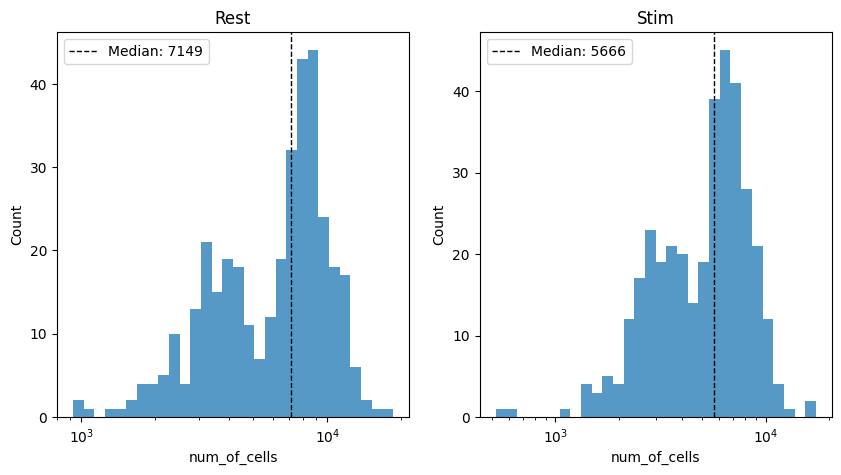

In [55]:
import seaborn as sns
fig, axes = plt.subplots(1,2, figsize = (10,5))
axes = axes.flatten()
sns.histplot(cell_count_rest, 
             x='num_of_cells', bins = 30, log_scale=True, edgecolor='none', linewidth=0,
            ax = axes[0])
axes[0].set_title('Rest')
median_rest = cell_count_rest['num_of_cells'].median()
axes[0].axvline(median_rest, color='black', linestyle='--', linewidth=1, label=f'Median: {median_rest:.0f}')
axes[0].legend()

sns.histplot(cell_count_stim, 
             x='num_of_cells', bins = 30, log_scale=True, edgecolor='none', linewidth=0,
            ax = axes[1])
axes[1].set_title('Stim')
median_stim = cell_count_stim['num_of_cells'].median()
axes[1].axvline(median_stim, color='black', linestyle='--', linewidth=1, label=f'Median: {median_stim:.0f}')
axes[1].legend()

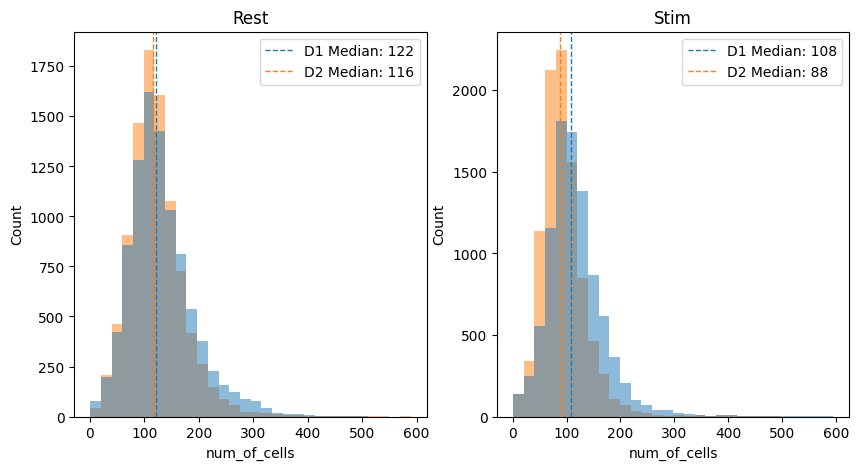

In [72]:
fig, axes = plt.subplots(1,2, figsize = (10,5))
axes = axes.flatten()
sns.histplot(cell_count_rest, 
             x='num_of_cells', bins = 30, hue = 'donor', edgecolor='none', linewidth=0,
            ax = axes[0])
axes[0].set_title('Rest')
medians = cell_count_rest.groupby('donor')['num_of_cells'].median()
colors = sns.color_palette() # Matches default seaborn colors

for i, (construct, val) in enumerate(medians.items()):
    axes[0].axvline(val, linestyle='--', linewidth=1, 
                    color=colors[i % len(colors)], 
                    label= f'{construct} Median: {val:.0f}')
axes[0].legend()
sns.histplot(cell_count_stim, 
             x='num_of_cells', bins = 30, hue = 'donor', edgecolor='none', linewidth=0,
            ax = axes[1])
axes[1].set_title('Stim')
medians = cell_count_stim.groupby('donor')['num_of_cells'].median()
colors = sns.color_palette() # Matches default seaborn colors

for i, (construct, val) in enumerate(medians.items()):
    axes[1].axvline(val, linestyle='--', linewidth=1, 
                    color=colors[i % len(colors)], 
                    label= f'{construct} Median: {val:.0f}')
axes[1].legend()

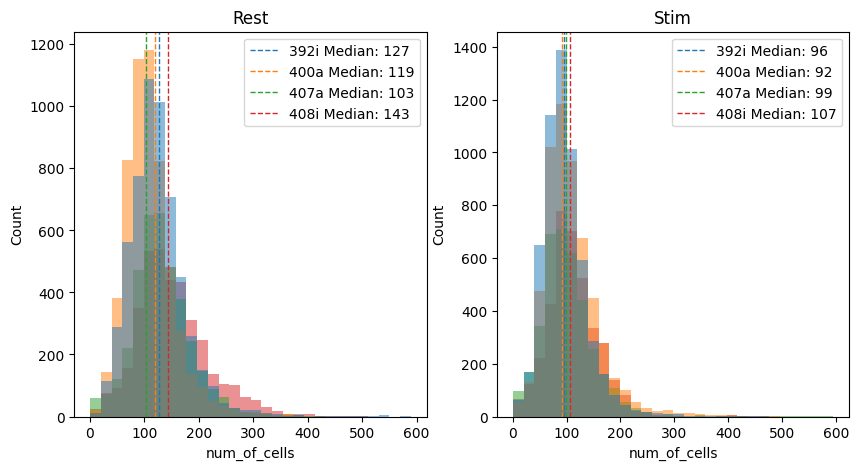

In [70]:
fig, axes = plt.subplots(1,2, figsize = (10,5))
axes = axes.flatten()
sns.histplot(cell_count_rest, 
             x='num_of_cells', bins = 30, hue = 'construct', edgecolor='none', linewidth=0,
            ax = axes[0])
axes[0].set_title('Rest')
# Inside your plotting loop for axes[0]
medians = cell_count_rest.groupby('construct')['num_of_cells'].median()
colors = sns.color_palette() # Matches default seaborn colors

for i, (construct, val) in enumerate(medians.items()):
    axes[0].axvline(val, linestyle='--', linewidth=1, 
                    color=colors[i % len(colors)], 
                    label= f'{construct} Median: {val:.0f}')
axes[0].legend()
sns.histplot(cell_count_stim, 
             x='num_of_cells', bins = 30, hue = 'construct', edgecolor='none', linewidth=0,
            ax = axes[1])
axes[1].set_title('Stim')
# Inside your plotting loop for axes[0]
medians = cell_count_stim.groupby('construct')['num_of_cells'].median()
colors = sns.color_palette() # Matches default seaborn colors

for i, (construct, val) in enumerate(medians.items()):
    axes[1].axvline(val, linestyle='--', linewidth=1, 
                    color=colors[i % len(colors)], 
                    label= f'{construct} Median: {val:.0f}')
axes[1].legend()